In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

### LLM Models Initialization

In [2]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing in your .env")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [3]:
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY is missing in your .env")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

### LLM Invocation

In [4]:
from langchain_groq import ChatGroq
chat_llm = ChatGroq(groq_api_key=GROQ_API_KEY, model_name="llama-3.3-70b-versatile", temperature=0.1)
chat_llm.invoke("Hello, how are you?").content

"Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?"

In [5]:
from langchain_google_genai import GoogleGenerativeAI
google_llm = GoogleGenerativeAI(model="gemini-3-flash-preview", temperature=0.1)
print(google_llm.invoke("Hello, how are you?"))

I'm doing well, thank you for asking! How are you doing today? Is there anything I can help you with?


In [6]:
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
import operator

class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [7]:
{"messages": [HumanMessage(content="Hi, this is Divyang. Say hello in detail.")]}

{'messages': [HumanMessage(content='Hi, this is Divyang. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [8]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])
    return {
        "messages": [response]
    }

In [9]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

### Workflow using Langgraph

In [10]:
from langgraph.graph import StateGraph

builder = StateGraph(GraphState)
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

app = builder.compile()
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

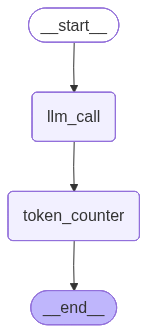

In [11]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
result = app.invoke({"messages": [HumanMessage(content="Hi, this is Divyang. Say hello in detail.")]})
result

{'messages': [HumanMessage(content='Hi, this is Divyang. Say hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello Divyang, it's a pleasure to meet you. I hope this message finds you in great spirits and having a fantastic day. I'm excited to connect with you and explore the various topics and interests you'd like to discuss. \n\nAs a friendly and knowledgeable assistant, I'm here to provide you with detailed and accurate information on a wide range of subjects, from science and history to entertainment and culture. Whether you have a specific question in mind or just want to engage in a fun conversation, I'm all ears and ready to help.\n\nPlease feel free to share a bit about yourself, your hobbies, or what's been on your mind lately. I'm looking forward to getting to know you better and providing you with a helpful and enjoyable experience. So, what's on your mind, Divyang? What would you like to talk about today?", additional_kwargs={}, response_

In [13]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Divyang. Say hello in detail.
AIMessage : Hello Divyang, it's a pleasure to meet you. I hope this message finds you in great spirits and having a fantastic day. I'm excited to connect with you and explore the various topics and interests you'd like to discuss. 

As a friendly and knowledgeable assistant, I'm here to provide you with detailed and accurate information on a wide range of subjects, from science and history to entertainment and culture. Whether you have a specific question in mind or just want to engage in a fun conversation, I'm all ears and ready to help.

Please feel free to share a bit about yourself, your hobbies, or what's been on your mind lately. I'm looking forward to getting to know you better and providing you with a helpful and enjoyable experience. So, what's on your mind, Divyang? What would you like to talk about today?
AIMessage : Total token number in the generated answer (word count) is 143


### Tools

In [14]:
# Wikipedia Tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max= 500)
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)
wiki_tool.run({"query":"Generative AI"})

'Page: Generative AI\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI tools has increased sig'

In [15]:
# Travily Tool
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)
tool.invoke({"query":"Highest Paying jobs in India in 2026 ?"})

C:\Users\divya\AppData\Local\Temp\ipykernel_31128\1081257914.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


[{'title': 'Top 10 Highest Paying Jobs in India [2026]',
  'url': 'https://agilemania.com/highest-paying-jobs-in-india',
  'content': 'Highest-Paying Jobs in India\n\nThe highest-paying jobs in India for 2026 are in areas of technology, management, and healthcare. Top professionals in these fields will make anywhere from ₹20 LPA to over ₹1 crore per year. Some of the leading high salary jobs include Investment Bankers, AI/ML Engineers, Data Scientists, Management Consultants, and Leadership Positions (CTO / CEO). [...] ## Quick Overview: Top 10 Highest Paying Jobs in India\n\n|  |  |\n --- |\n| Job Role | Approx. Salary Range (India) |\n| Leadership Positions (CTO / CEO) | ₹50 LPA – ₹350 LPA+ |\n| AI & Machine Learning Roles | ₹7 LPA – ₹60 LPA+ |\n| Data Scientist | ₹6 LPA – ₹40 LPA+ |\n| Management Consulting | ₹25 LPA – ₹75 LPA+ |\n| Investment Bankers | ₹30 LPA – ₹1 Cr+ |\n| Project Managers | ₹15 LPA – ₹30 LPA+ |\n| Scrum Masters | ₹7 LPA – ₹20 LPA |\n| Software Architect | ₹20 LPA

In [16]:
# Duck Duck Go Search Tool
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

search.invoke("what is the latest update on Iran-USA War?")

"Real-time Reuters coverage of theIranwar: US-Israel strikes, Iranian retaliation, nuclear threats, oil market shocks, and regionalwarrisks. Irandowned a US fighter jet. Could that change the calculus ofwar? Foundation for Defense of Democracies' Behnam Ben Taleblu discusses thelatestdevelopments in theIranwar. Iran'sIRGC intelligence chief killed by IDF airstrike as Israel vows to hunt down regime leaders 'one by one' - liveupdatesPakistan puts forward proposal to end hostilities and exchanges it ... Trump's threat to destroyIran'spower plants and bridges if it doesn't make a deal to end thewarby Tuesday is looming over a Pakistani ceasefire push. Latestnews today from the Middle East asIran-USwarcontinues. Follow for liveupdates"

In [17]:
# YouTube Search Tool
from langchain_community.tools import YouTubeSearchTool

tool=YouTubeSearchTool()
print("Tool name:", tool.name)
print("Tool description:", tool.description)
tool.run("Best Agentic AI videos on YouTube")

Tool name: youtube_search
Tool description: search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional


"['https://www.youtube.com/watch?v=8FvuPHXPdcY&pp=ygUhQmVzdCBBZ2VudGljIEFJIHZpZGVvcyBvbiBZb3VUdWJl0gcJCdkKAYcqIYzv', 'https://www.youtube.com/watch?v=hpc5DO2dC-4&pp=ygUhQmVzdCBBZ2VudGljIEFJIHZpZGVvcyBvbiBZb3VUdWJl']"

### Custom Tools

In [18]:
from langchain.tools import tool

@tool
def multiply(a:int,b:int) -> int:
    '''This tool is for the multiplication'''
    return a*b

print(multiply.invoke({"a":10,"b":20}))

print("Tool name:", multiply.name)
print("Tool description:", multiply.description)
print("Tool Args:", multiply.args)

200
Tool name: multiply
Tool description: This tool is for the multiplication
Tool Args: {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [19]:
@tool
def get_word_length(word:str) -> int:
    """it is a tool to count the length of the word"""
    return len(word)

print(get_word_length.invoke("hello world"))

print("Tool name:", get_word_length.name)
print("Tool description:", get_word_length.description)
print("Tool Args:", get_word_length.args)

11
Tool name: get_word_length
Tool description: it is a tool to count the length of the word
Tool Args: {'word': {'title': 'Word', 'type': 'string'}}


In [20]:
# yfinance Tool - Yahoo finance fetch real time stock price

import yfinance as yf

@tool
def get_stock_price(ticker:str) -> str: 
    """This is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }
        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"

In [21]:
print(get_stock_price.invoke("TCS.NS"))
print(get_stock_price.invoke("AAPL"))

The last closing price of TCS.NS was ₹2473.90.
The last closing price of AAPL was $255.92.


### LLM Calling with tools

In [22]:
tools = [get_stock_price,get_word_length,multiply]
llm_with_tools=chat_llm.bind_tools(tools)

result = llm_with_tools.invoke("what is the stock price of TCS.NS?")
print("Result:", result)
print("Content: ", result.content)
print("Tool calls made during the invocation:")

for tool_call in result.tool_calls:
    print(f" - {tool_call['name']}: {tool_call['args']}")

Result: content='' additional_kwargs={'tool_calls': [{'id': '6afyng6gj', 'function': {'arguments': '{"ticker":"TCS.NS"}', 'name': 'get_stock_price'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 355, 'total_tokens': 373, 'completion_time': 0.050738614, 'completion_tokens_details': None, 'prompt_time': 0.023347642, 'prompt_tokens_details': None, 'queue_time': 0.307843883, 'total_time': 0.074086256}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_e65acd3773', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d62ab-8d76-7eb0-9c7d-7ac31ca045fa-0' tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': '6afyng6gj', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 355, 'output_tokens': 18, 'total_tokens': 373}
Content:  
Tool calls made during the invocation:
 - get_stock_price: {'ticker': 'TCS.NS'}


In [23]:
result = llm_with_tools.invoke("can you multiply 10 and 20?")
print("Result:", result)
print("Content: ", result.content)
print("Tool calls made during the invocation:")
for tool_call in result.tool_calls:
    print(f" - {tool_call['name']}: {tool_call['args']}")

Result: content='' additional_kwargs={'tool_calls': [{'id': 'qp87mgw41', 'function': {'arguments': '{"a":10,"b":20}', 'name': 'multiply'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 353, 'total_tokens': 372, 'completion_time': 0.071683564, 'completion_tokens_details': None, 'prompt_time': 0.019121541, 'prompt_tokens_details': None, 'queue_time': 0.204278029, 'total_time': 0.090805105}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d62ab-8f8c-7403-92b1-9bbfb17564b6-0' tool_calls=[{'name': 'multiply', 'args': {'a': 10, 'b': 20}, 'id': 'qp87mgw41', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 353, 'output_tokens': 19, 'total_tokens': 372}
Content:  
Tool calls made during the invocation:
 - multiply: {'a': 10, 'b': 20}


### Reflection Pattern Workflow

In [24]:
from langchain_core.messages import HumanMessage, SystemMessage 
from langgraph.graph import MessagesState,StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")


In [25]:
def ai_response(state:MessagesState):
    user_question = state["messages"]
    input_question = [SYSTEM_PROMPT] + user_question
    response = llm_with_tools.invoke(input_question)

    return{"messages":[response]}

In [26]:
agent_skills = ToolNode(tools)
agent_skills

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'get_stock_price': StructuredTool(name='get_stock_price', description='This is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x0000023EA9254FE0>), 'get_word_length': StructuredTool(name='get_word_length', description='it is a tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x0000023EADE82700>), 'multiply': StructuredTool(name='multiply', description='This tool is for the multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000023EA9254B80>)}, _injected_args={'get_stock_price': _InjectedArgs(state={}, store=None, runtime=None, all_injected_keys=set()), 'get_word_length': 

In [27]:
workflow = StateGraph(MessagesState)
workflow.add_node("llm", ai_response)
workflow.add_node("tools", agent_skills)
workflow.add_edge(START, "llm")

workflow.add_conditional_edges("llm", tools_condition,)

workflow.add_edge("tools", "llm")
app = workflow.compile()

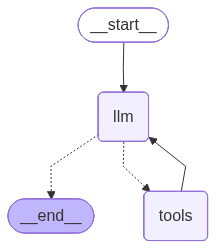

In [28]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [29]:
result = app.invoke({"messages": [HumanMessage(content="what is the stock price of TCS.NS?")]})

In [30]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the stock price of TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (8jtb4me88)
 Call ID: 8jtb4me88
  Args:
    ticker: TCS.NS
================================= Tool Message =================================
Name: get_stock_price

The last closing price of TCS.NS was ₹2473.90.
================================== Ai Message ==================================

The current stock price of TCS.NS is ₹2473.90.
